# Краткий отчет

Модель явно переобучается, это можно увидеть на небольших графиках по динамике AUC во время обучения. Поэтому первое, что я сделал - в два раза уменьшил размерность скрытого слоя.

1. `Hidden size` 256 -> 128

Модель все равно переобучалась, поэтому я выкрутил дропаут в 0.5. Стало лучше, но модель все равно очень быстро начинала давать хуже AUC на валидации.

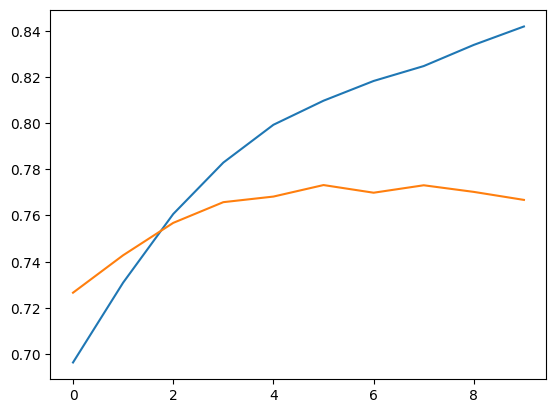

*После уменьшения параметров модель все равно переобучается*

2. `Dropout` 0.25 -> 0.5


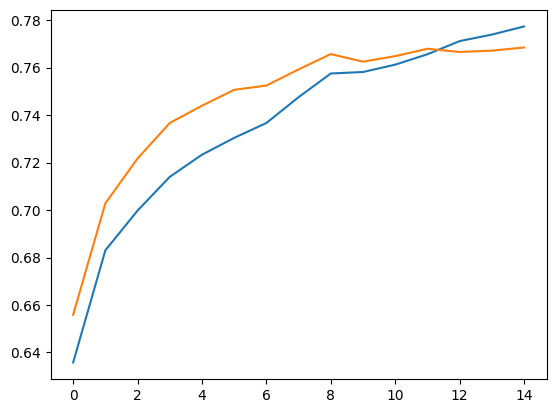

*Dropout: 0.7*

Модель все еще переобучалась за 4-5 эпох и AUC на обучающей выборке продолжал расти, поэтому я увеличил label_smoothing до 0.01 и прибавил weight_decay до 1e-4. Также перешел на AdamW, так как обычный Adam вроде плохо работает с Weight Decay.

3. `Weight Decay` 5e-5 -> 1e-2

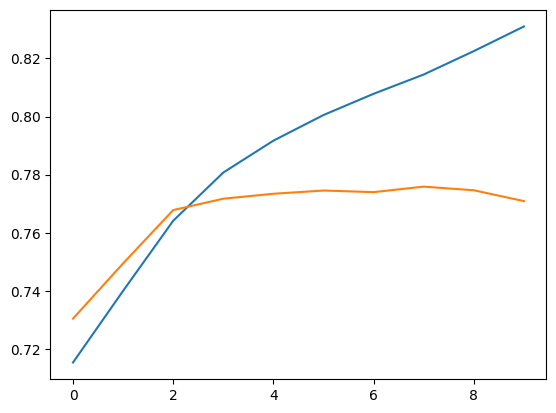
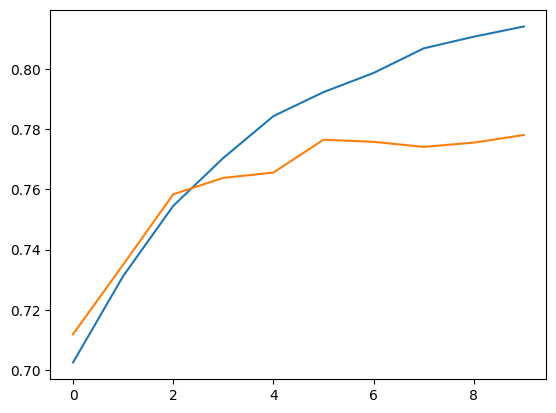

*Графики до и после увееличения L2 регуляризации*

1. `AdamW`
2. `Label smoothing` 0.0001 -> 0.03

Также чтобы урезать модель я убрал из конволюций фактор add вообще и понизил колчество других.

6.
```
conv1_aggrs {'mean':128, 'max':64, 'add':32} -> {'mean':64, 'max':32}
```
```
conv1_aggrs {'mean': 64, 'max':16, 'add':8} -> {'mean': 32, 'max':16}
```

Также для стабильности обучения я добавил батч норму и заменил шедулер на более привычный для меня `ReduceLROnPlateau`. Возможно чуть позже добавлю еще вармап. Как его называт наш лектор по методам оптимизации - "прогрев".

7. `BatchNorm1d` + `ReduceLROnPlateau`

Мне стало интересно, почему в ноутбуке имортируется новая конволюция и она мне немного подняла качество, возможно это связанно с более гомофильной структурой графа, которую эта свертка учитывает лучше.

8. `GraphConv` -> `SAGEConv`

В качестве дополнительной регуляризации будем в лоадере брать не всех соседей, а только часть. Я остановился на этом параметре, так как если брать меньше, модель полностью перестает переобучаться, но при этом уже начинает терять в качестве на валидации.

9. `num_neighbors` [-1, -1] -> [25, 10]

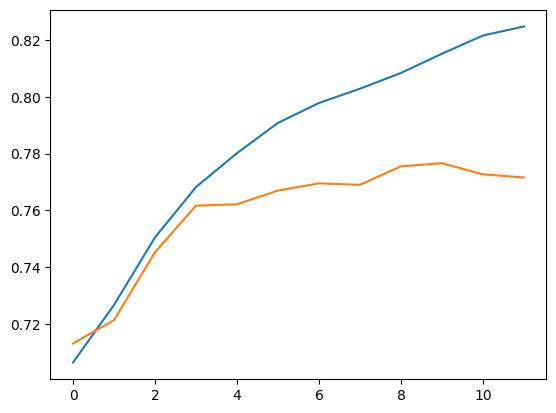

*Neighbours: [30, 20]*

Дополнение: Я еще поигрался с `Dropout` и оставил пока на 0.6 и вернул сумму в свертку. Возможно позже добавлю обратно параметры и подниму `Dropout` до 0.7. Если честно, вперые сталкиваюсь с задачей, где рассматриваю такие большие дропауты. Хотя по смыслу такие дропауты это как обучение сразу ансамбля моделей и это может дать дополнительный прирост в качестве. Также возможно стоит попробовать буквально какое-то ансамблирование добавить, так как из-за низкого времени обучения и сильного переобучения это может быть хорошим вариантом.

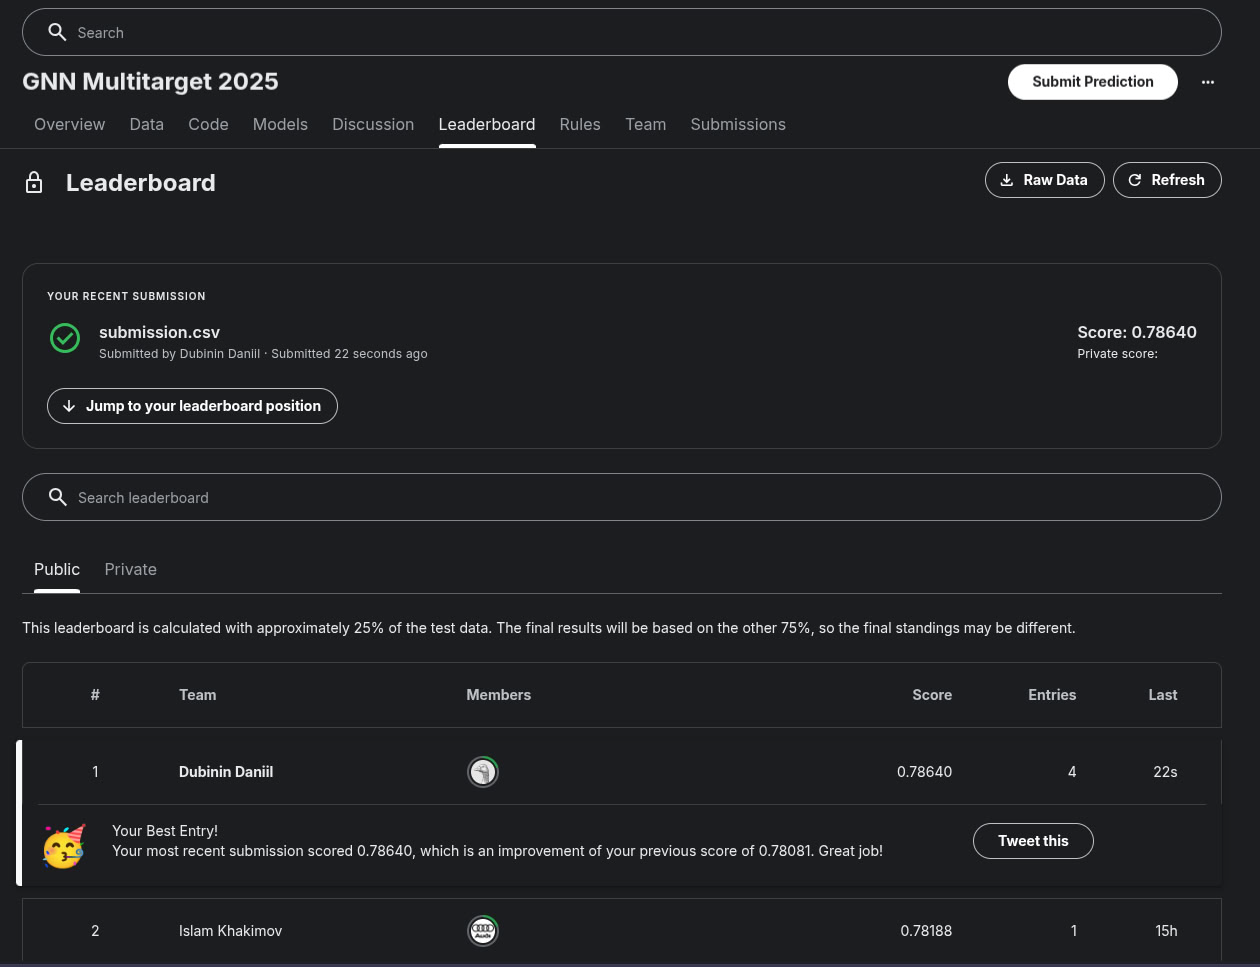